# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Reproduction of Barber et al. (2022)

---

## Foreword

In this notebook, the purpose is to reproduce the figure 1 in Barber et al. (2022). 

## 1. Libraries & Data

I first load the relevant libraries and data.

In [2]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# data
df = pd.read_csv("../../../data/processed/CRSP_RH_TAQ_merged.csv")

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_10030/353368278.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../data/processed/CRSP_RH_TAQ_merged.csv")


## 2. Time Series

Once I have loaded the data, I isolate the relevant time series but first I drop the rows where `users_close` are nan.

In [3]:
# Robinhood total user stock holdings
df["total_users_close"] = df['users_close'].groupby(df['date']).transform('sum') / 1e6

# TAQ total retail trade volume
df["total_retail_volume_num"] = df['total_trade_retail'].groupby(df['date']).transform('sum') / 1e6

# date column to datetime
df["date"] = pd.to_datetime(df["date"])

I realize the first plot.

In [4]:
# custom HSG colors
green = (24/255, 127/255, 56/255)
beige = (188/255, 169/255, 128/255)
red = (229/255, 110/255, 108/255)

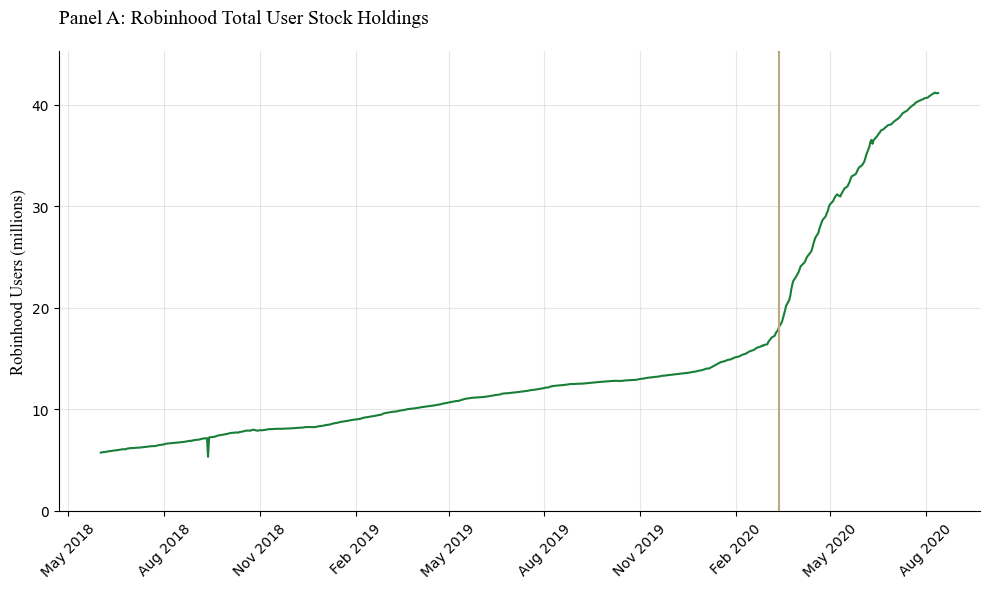

In [6]:
# keep one row per date and drop rows with total_users_close = 0
df_plot = (
    df[["date", "total_users_close"]]
    .dropna()
    .sort_values("date")
    .query("total_users_close != 0")
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    df_plot["date"],
    df_plot["total_users_close"],
    linestyle='-',
    color=green
)

ax.axvline(
    x=pd.Timestamp("2020-03-13"),
    color=beige,
    linestyle='-'
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax.set_title('Panel A: Robinhood Total User Stock Holdings', fontsize=14, pad=20, loc='left',
             family="Times New Roman")
# ax.set_xlabel('Date', fontsize=12, family="Times New Roman")
ax.set_ylim(0, df_plot["total_users_close"].max() * 1.1)
ax.set_ylabel('Robinhood Users (millions)', fontsize=12, family="Times New Roman")
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../../figures/total_RH_users_close.pdf", bbox_inches='tight')
plt.show()

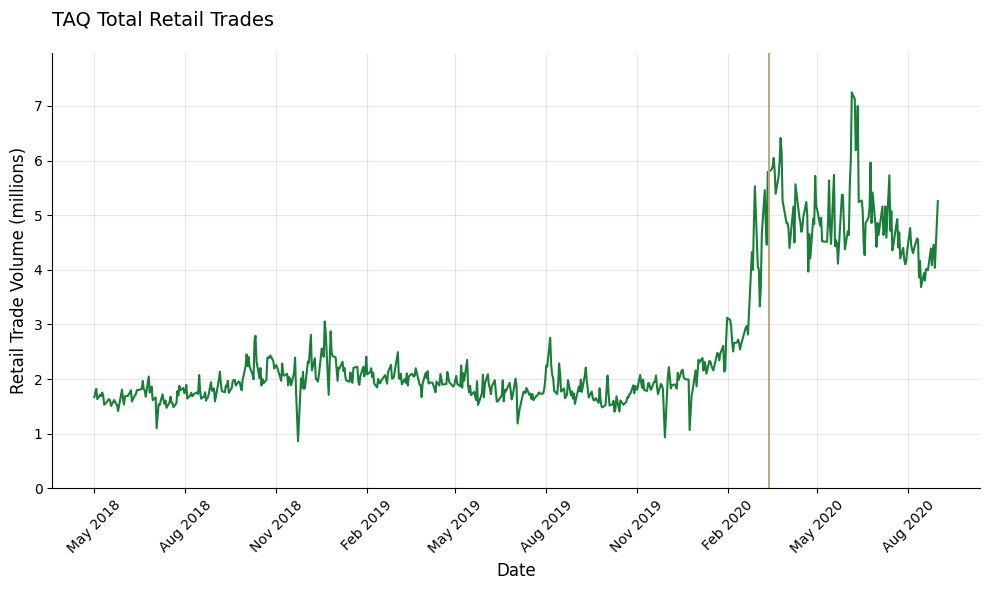

In [7]:
# same for total retail volume
df_plot2 = (
    df[["date", "total_retail_volume_num"]]
    .dropna()
    .sort_values("date")
    .query("total_retail_volume_num != 0")
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    df_plot2["date"],
    df_plot2["total_retail_volume_num"],
    linestyle='-',
    color=green
)

ax.axvline(
    x=pd.Timestamp("2020-03-13"),
    color=beige,
    linestyle='-'
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax.set_title('TAQ Total Retail Trades', fontsize=14, pad=20, loc='left')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylim(0, df_plot2["total_retail_volume_num"].max() * 1.1)
ax.set_ylabel('Retail Trade Volume (millions)', fontsize=12)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../../figures/total_retail_volume.pdf", bbox_inches='tight')
plt.show()

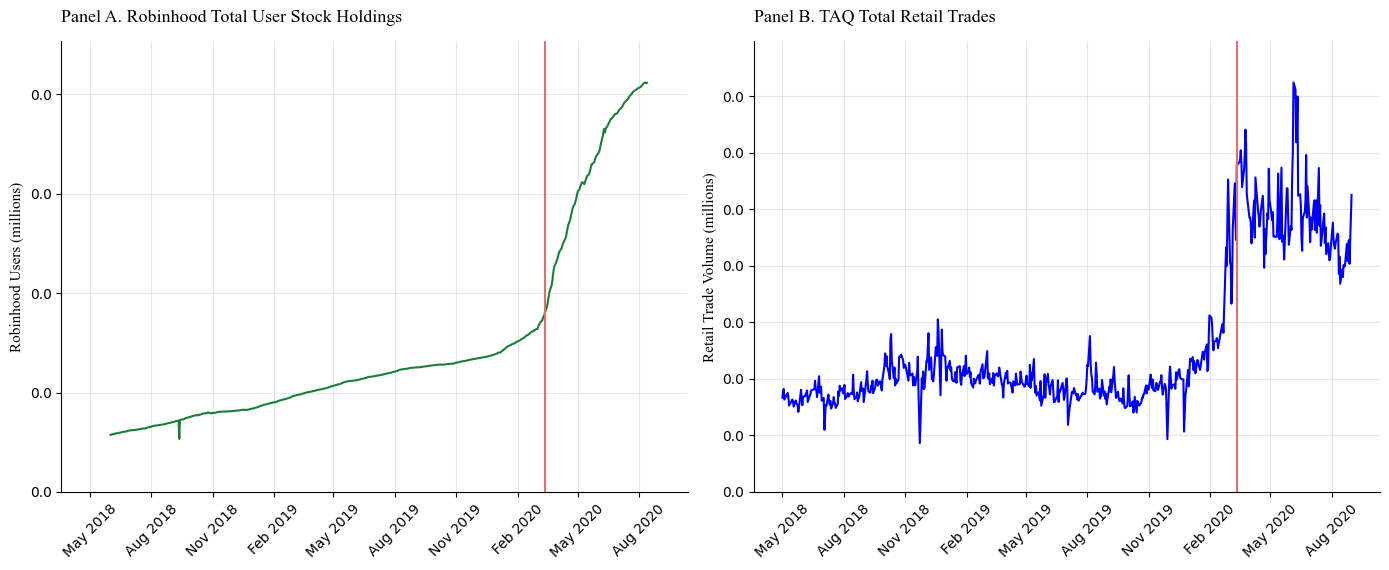

In [10]:
from matplotlib.ticker import FuncFormatter

# keep one row per date and drop rows with zeros
df_plot = (
    df[["date", "total_users_close"]]
    .dropna()
    .sort_values("date")
    .query("total_users_close != 0")
    .drop_duplicates(subset=["date"])
)

df_plot2 = (
    df[["date", "total_retail_volume_num"]]
    .dropna()
    .sort_values("date")
    .query("total_retail_volume_num != 0")
    .drop_duplicates(subset=["date"])
)

# optional: formatter if your variables are already in raw counts
millions_fmt = FuncFormatter(lambda x, pos: f"{x/1e6:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), sharex=True)

# -----------------------------
# Panel A: Robinhood users
# -----------------------------
axes[0].plot(
    df_plot["date"],
    df_plot["total_users_close"],
    linestyle="-",
    color=green,
    linewidth=1.5
)

axes[0].axvline(
    x=pd.Timestamp("2020-03-13"),
    color=red,
    linestyle="-",
    linewidth=1.5
)

axes[0].set_title(
    "Panel A. Robinhood Total User Stock Holdings",
    fontsize=13,
    pad=14,
    loc="left",
    family="Times New Roman"
)
axes[0].set_ylabel(
    "Robinhood Users (millions)",
    fontsize=11,
    family="Times New Roman"
)
axes[0].set_ylim(0, df_plot["total_users_close"].max() * 1.1)
axes[0].yaxis.set_major_formatter(millions_fmt)
axes[0].grid(alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# -----------------------------
# Panel B: TAQ retail volume
# -----------------------------
axes[1].plot(
    df_plot2["date"],
    df_plot2["total_retail_volume_num"],
    linestyle="-",
    color="blue",
    linewidth=1.5
)

axes[1].axvline(
    x=pd.Timestamp("2020-03-13"),
    color=red,
    linestyle="-",
    linewidth=1.5
)

axes[1].set_title(
    "Panel B. TAQ Total Retail Trades",
    fontsize=13,
    pad=14,
    loc="left",
    family="Times New Roman"
)
axes[1].set_ylabel(
    "Retail Trade Volume (millions)",
    fontsize=11,
    family="Times New Roman"
)
axes[1].set_ylim(0, df_plot2["total_retail_volume_num"].max() * 1.1)
axes[1].yaxis.set_major_formatter(millions_fmt)
axes[1].grid(alpha=0.3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# -----------------------------
# Shared x-axis formatting
# -----------------------------
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="both", labelsize=10)

fig.tight_layout()
fig.savefig("../../../figures/rh_users_and_taq_volume_side_by_side.pdf", bbox_inches="tight")
plt.show()

Lastly, I plots the total number of absolute Robinhood user changes (green) and absolute TAQ net buys (blue) as a five days moving average.

In [12]:
# 1) Robinhood: stock-level daily user change
rh = df.sort_values(["ticker", "date"]).copy()
rh["userchg"] = rh.groupby("ticker")["users_close"].diff()

# 2) Daily sum across stocks of absolute user changes
rh_daily = (
    rh.groupby("date", as_index=False)["userchg"]
      .apply(lambda x: x.abs().sum())
      .rename(columns={"userchg": "abs_userchg_sum"})
      .sort_values("date")
)

# 3) 5-day moving average and divide by 1e3 to get in thousands
rh_daily["abs_userchg_sum_ma5"] = (
    rh_daily["abs_userchg_sum"].rolling(window=5, min_periods=5).mean()
)

rh_daily["abs_userchg_sum_ma5"] /= 1e3

# 4) TAQ: stock-level absolute net buys
taq = df.sort_values(["ticker", "date"]).copy()
taq["abs_net_buy"] = (taq["buy_num_trades_retail"] - taq["sell_num_trades_retail"]).abs()

# 5) Daily sum across stocks
taq_daily = (
    taq.groupby("date", as_index=False)["abs_net_buy"]
       .sum()
       .sort_values("date")
)

# 6) 5-day moving average
taq_daily["abs_net_buy_ma5"] = (
    taq_daily["abs_net_buy"].rolling(window=5, min_periods=5).mean()
)

taq_daily["abs_net_buy_ma5"] /= 1e3

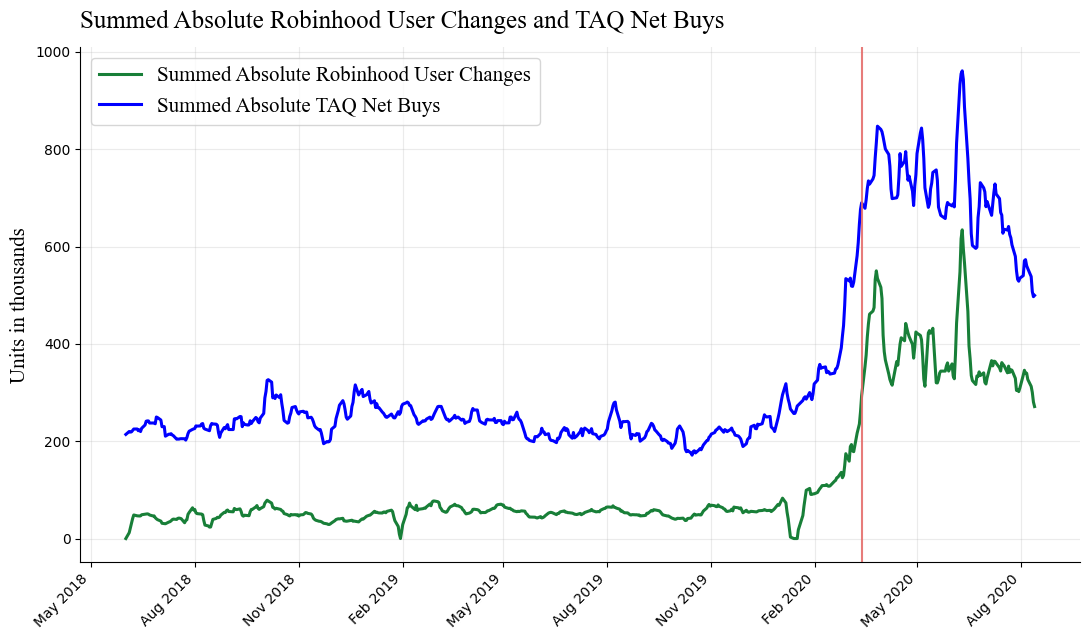

In [14]:
# merge daily series for plotting
plot_df = pd.merge(
    rh_daily[["date", "abs_userchg_sum_ma5"]],
    taq_daily[["date", "abs_net_buy_ma5"]],
    on="date",
    how="inner"
).sort_values("date")

# clip the dates between 1st of June 2018 and 13th of August 2020
plot_df = plot_df[
    (plot_df["date"] >= pd.Timestamp("2018-06-01")) &
    (plot_df["date"] <= pd.Timestamp("2020-08-13"))
]

# The plot
###########
fig, ax = plt.subplots(figsize=(11, 6.5))

ax.plot(
    plot_df["date"],
    plot_df["abs_userchg_sum_ma5"],
    color=green,
    linewidth=2.2,
    label="Summed Absolute Robinhood User Changes"
)

ax.plot(
    plot_df["date"],
    plot_df["abs_net_buy_ma5"],
    color="blue",
    linewidth=2.2,
    label="Summed Absolute TAQ Net Buys"
)

ax.axvline(
    pd.Timestamp("2020-03-13"),
    color=red,
    linewidth=1.5,
    alpha=0.9
)

ax.set_ylabel("Units in thousands", fontsize=15, family="Times New Roman")
ax.set_xlabel("")
ax.set_title(
    "Summed Absolute Robinhood User Changes and TAQ Net Buys",
    fontsize=18,
    loc="left",
    pad=14,
    family="Times New Roman"
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.grid(axis="both", alpha=0.25, linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper left", frameon=True, fontsize=13, prop={"family": "Times New Roman", "size": 15})

fig.tight_layout()
plt.savefig(
    "../../../figures/RH_user_changes_TAQ_retail_net_buys_clean.pdf",
    bbox_inches="tight"
)
plt.show()